# FullereneNet — Dataset Exploration

Three datasets are used in training:

| Name | Molecules | Size range | Split role |
|------|-----------|------------|------------|
| `c60` | 5770 | C20–C60 | train/val (C20–C58) + test (C60) |
| `c70_non_IPR` | 100 | C70 non-IPR | external test |
| `c72_100_IPR` | 1230 | C72–C100 IPR | external test |

Each molecule has 4 feature tensors: **node**, **edge index**, **edge**, **ring (pentagon)**, **ring (hexagon)**.

In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams['figure.dpi'] = 120

## 1. Load Feature Files

In [2]:
FEAT = 'feature/'

datasets = {}
for name in ['c60', 'c70_non_IPR', 'c72_100_IPR']:
    datasets[name] = {
        'node':      torch.load(f'{FEAT}node_feature_{name}.pt'),
        'edge_idx':  torch.load(f'{FEAT}edge_index_{name}.pt'),
        'edge':      torch.load(f'{FEAT}edge_feature_{name}.pt'),
        'pent':      torch.load(f'{FEAT}ring_feature_pentagon_{name}.pt'),
        'hex':       torch.load(f'{FEAT}ring_feature_hexagon_{name}.pt'),
    }

labels = {
    'c60':         pd.read_csv('data/c20-c60-dft-all.csv'),
    'c70_non_IPR': pd.read_csv('data/c70-100-isomers-Eb-Eg-logP.csv'),
    'c72_100_IPR': pd.read_csv('data/c62-c720-dft-all.csv'),
}

print('Loaded datasets:')
for name, d in datasets.items():
    print(f'  {name}: {len(d["node"])} molecules')

Loaded datasets:
  c60: 5770 molecules
  c70_non_IPR: 100 molecules
  c72_100_IPR: 1230 molecules


## 2. Feature Descriptions

### Node feature — shape `(N_atoms, 4)`
Each atom is encoded by how many of its 3 neighbouring rings are pentagons:

| Index | Meaning |
|-------|---------|
| 0 | 3 pentagons (all neighbours pentagon) |
| 1 | 2 pentagons |
| 2 | 1 pentagon |
| 3 | 0 pentagons (all neighbours hexagon) |

### Edge feature — shape `(N_bonds, 9)`
Each bond is surrounded by 4 rings. The pattern of pentagon (P) / hexagon (H) around those 4 rings maps to one of 9 symmetry classes (I–IX, i.e. HHHH → PPPP).

### Ring feature pentagon — shape `(12, 8)`
Every fullerene has exactly 12 pentagons. Each pentagon is classified by its 5 surrounding rings into 8 types (P0–P5).

### Ring feature hexagon — shape `(N_hex, 13)`
Each hexagon is classified by its 6 surrounding rings into 13 types (H0–H6).

In [3]:
# Show tensor shapes for one example molecule from each dataset
print(f"{'Feature':<18} {'c60[0]':<22} {'c70_non_IPR[0]':<22} {'c72_100_IPR[0]'}")
print('-' * 80)
for key, label in [('node','node'), ('edge_idx','edge_index'), ('edge','edge'), ('pent','pent_ring'), ('hex','hex_ring')]:
    shapes = [str(tuple(datasets[n][key][0].shape)) for n in ['c60','c70_non_IPR','c72_100_IPR']]
    print(f"  {label:<16} {shapes[0]:<22} {shapes[1]:<22} {shapes[2]}")

Feature            c60[0]                 c70_non_IPR[0]         c72_100_IPR[0]
--------------------------------------------------------------------------------
  node             (20, 4)                (70, 4)                (72, 4)
  edge_index       (2, 60)                (2, 210)               (2, 216)
  edge             (60, 9)                (210, 9)               (216, 9)
  pent_ring        (12, 8)                (12, 8)                (12, 8)
  hex_ring         (1, 13)                (25, 13)               (26, 13)


## 3. Example Molecule

In [4]:
# C60 (Buckminsterfullerene) is the last entry in the c60 dataset
idx = -1  # last molecule = C60
d = datasets['c60']

print('=== C60 example (last entry in c60 dataset) ===')
print(f'Atoms:          {d["node"][idx].shape[0]}')
print(f'Bonds:          {d["edge_idx"][idx].shape[1]}')
print(f'Pentagons:      {d["pent"][idx].shape[0]}')
print(f'Hexagons:       {d["hex"][idx].shape[0]}')
print()
print('Node features (first 5 atoms):')
print(d['node'][idx][:5])
print()
print('Edge features (first 5 bonds):')
print(d['edge'][idx][:5])
print()
print('Pentagon ring features (all 12):')
print(d['pent'][idx])

=== C60 example (last entry in c60 dataset) ===
Atoms:          60
Bonds:          180
Pentagons:      12
Hexagons:       20

Node features (first 5 atoms):
tensor([[1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.]])

Edge features (first 5 bonds):
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1.]])

Pentagon ring features (all 12):
tensor([[0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 

## 4. Dataset Size Statistics

In [13]:
for name, d in datasets.items():
    n_atoms  = [t.shape[0] for t in d['node']]
    n_bonds  = [t.shape[1] for t in d['edge_idx']]
    n_hex    = [t.shape[0] for t in d['hex']]
    print(f'--- {name} ---')
    print(f'  Molecules : {len(n_atoms)}')
    print(f'  Atoms     : min={min(n_atoms)}, max={max(n_atoms)}, unique={sorted(set(n_atoms))}')
    print(f'  Bonds     : min={min(n_bonds)}, max={max(n_bonds)}')
    print(f'  Hexagons  : min={min(n_hex)}, max={max(n_hex)}')
    print()

--- c60 ---
  Molecules : 5770
  Atoms     : min=20, max=60, unique=[20, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60]
  Bonds     : min=60, max=180
  Hexagons  : min=1, max=20

--- c70_non_IPR ---
  Molecules : 100
  Atoms     : min=70, max=70, unique=[70]
  Bonds     : min=210, max=210
  Hexagons  : min=25, max=25

--- c72_100_IPR ---
  Molecules : 1230
  Atoms     : min=72, max=100, unique=[72, 74, 76, 78, 80, 82, 84, 86, 90, 92, 94, 96, 98, 100]
  Bonds     : min=216, max=300
  Hexagons  : min=26, max=40



## 5. Label Statistics

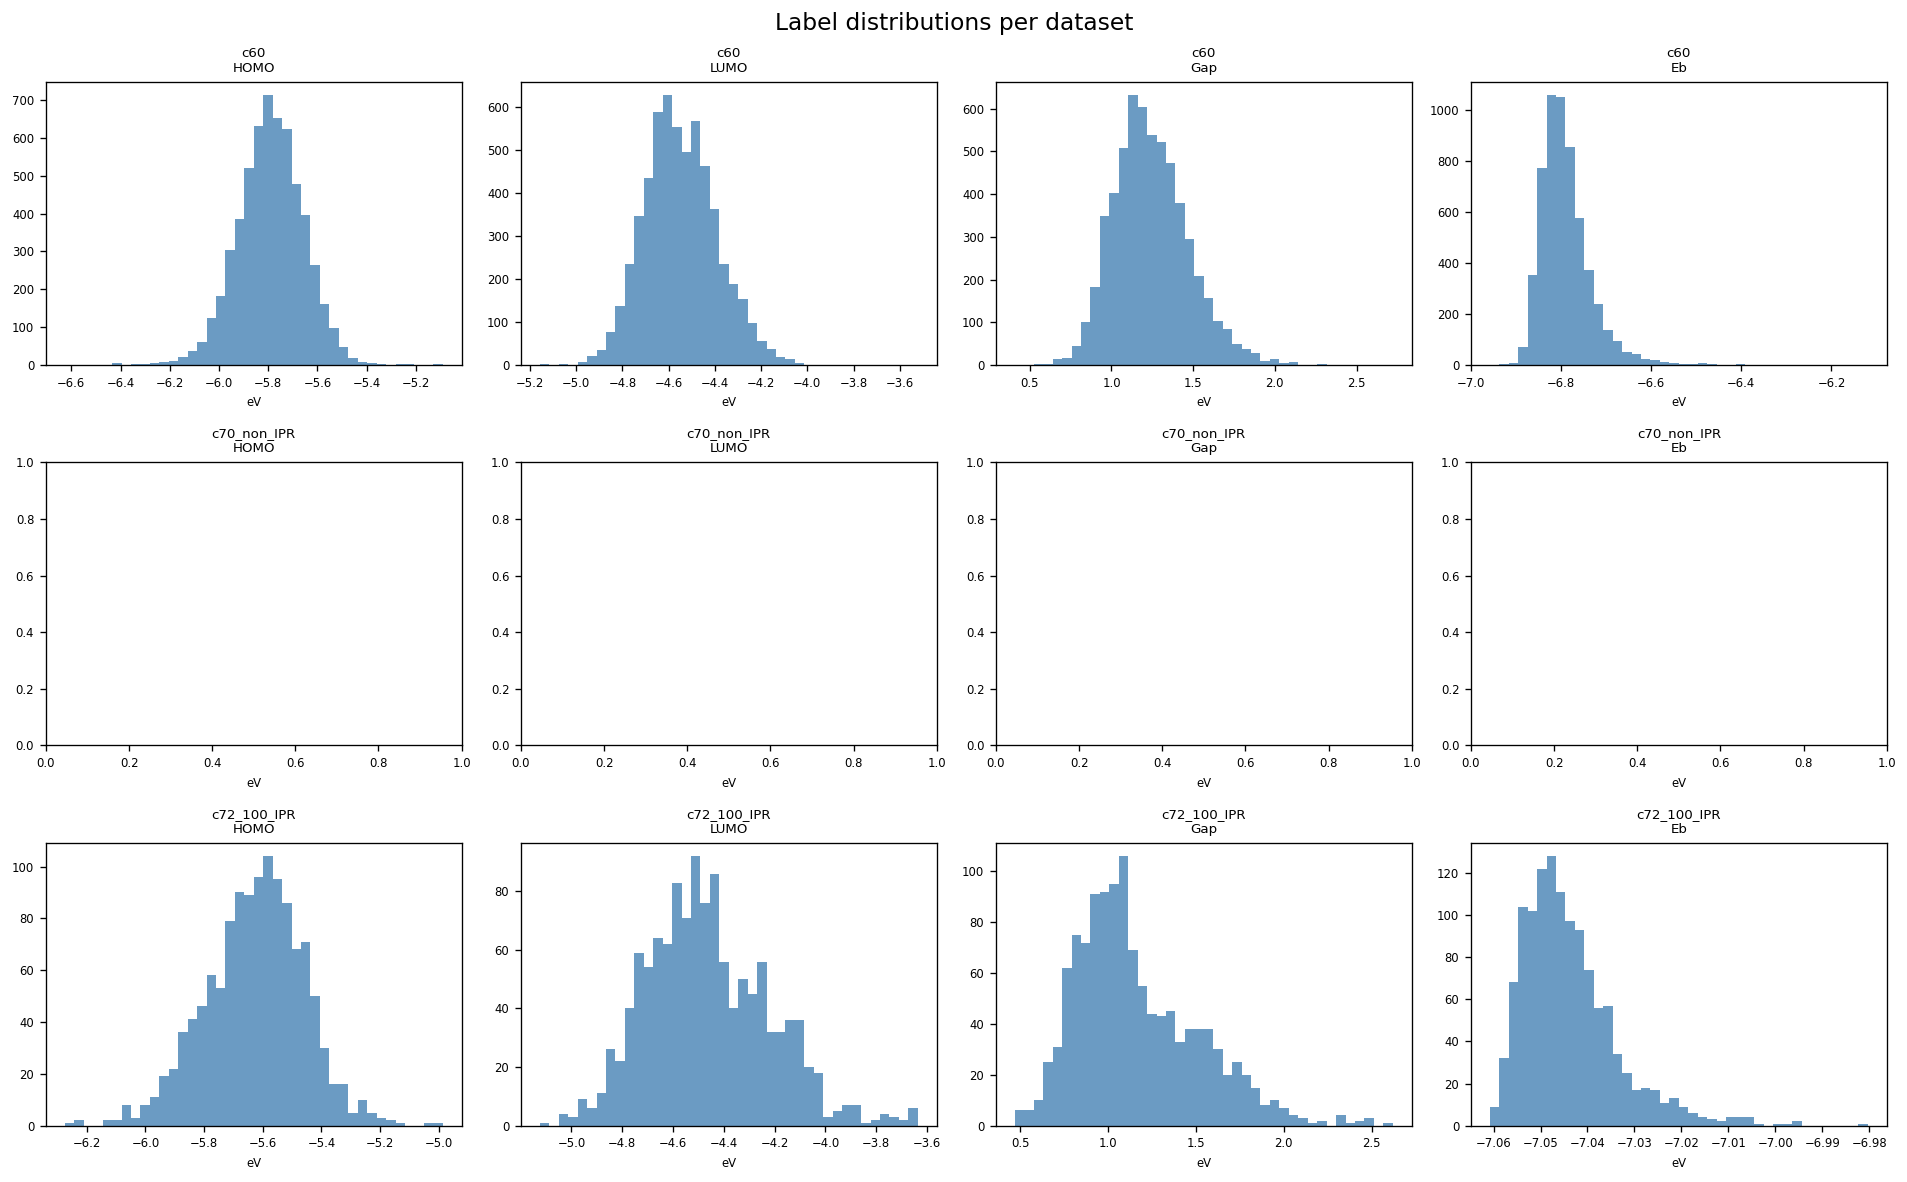

In [6]:
target_cols = {
    'c60':         {'HOMO(eV)': 'HOMO', 'LUMO(eV)': 'LUMO', 'HOMO-LUMO(eV)': 'Gap', 'E_binding(eV)': 'Eb'},
    'c70_non_IPR': {'HOMO': 'HOMO', 'LUMO': 'LUMO', 'Gap': 'Gap', 'Eb': 'Eb'},
    'c72_100_IPR': {'HOMO(eV)': 'HOMO', 'LUMO(eV)': 'LUMO', 'HOMO-LUMO(eV)': 'Gap', 'E_binding(eV)': 'Eb'},
}

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Label distributions per dataset', fontsize=14)

for row, (name, col_map) in enumerate(target_cols.items()):
    df = labels[name]
    for col_idx, (col, label) in enumerate(col_map.items()):
        ax = axes[row, col_idx]
        if col in df.columns:
            ax.hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='none', alpha=0.8)
        ax.set_title(f'{name}\n{label}', fontsize=8)
        ax.set_xlabel('eV', fontsize=7)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

## 6. Node Feature Distribution
How often does each atom type appear across the c60 dataset?

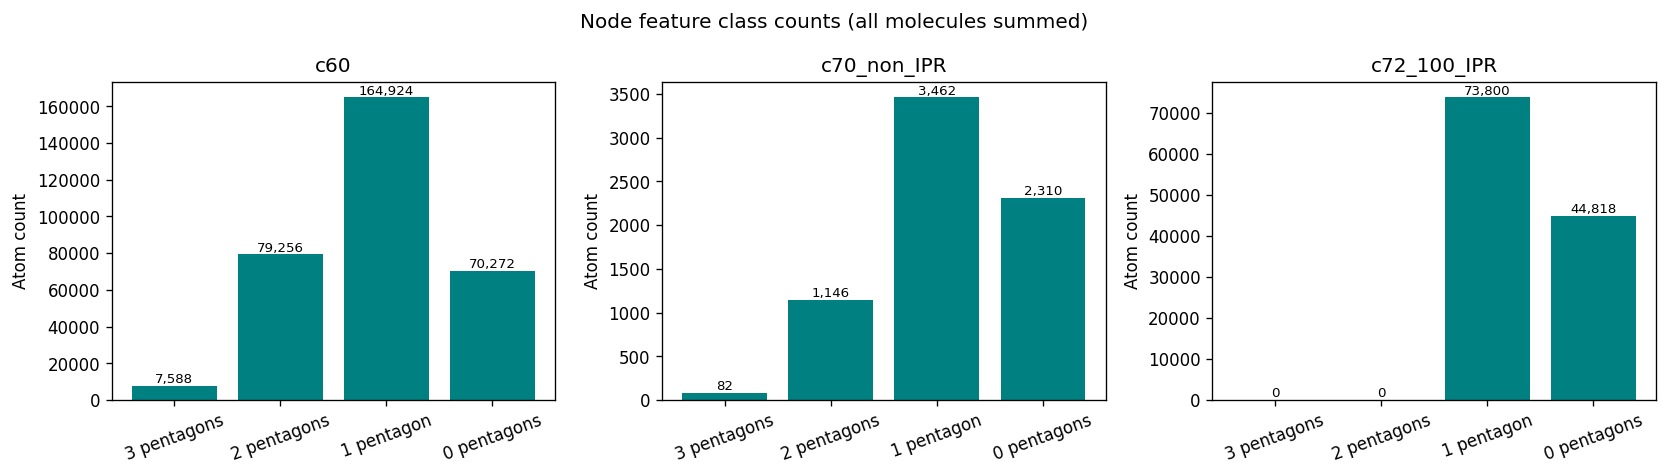

In [7]:
node_labels = ['3 pentagons', '2 pentagons', '1 pentagon', '0 pentagons']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Node feature class counts (all molecules summed)', fontsize=12)

for ax, name in zip(axes, ['c60', 'c70_non_IPR', 'c72_100_IPR']):
    all_nodes = torch.cat(datasets[name]['node'], dim=0)  # (total_atoms, 4)
    counts = all_nodes.sum(dim=0).numpy()
    ax.bar(node_labels, counts, color='teal')
    ax.set_title(name)
    ax.set_ylabel('Atom count')
    ax.tick_params(axis='x', rotation=20)
    for i, v in enumerate(counts):
        ax.text(i, v + max(counts)*0.01, f'{int(v):,}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## 7. Edge Feature Distribution
Each bond maps to one of 9 ring-pattern classes (I=HHHH … IX=PPPP).

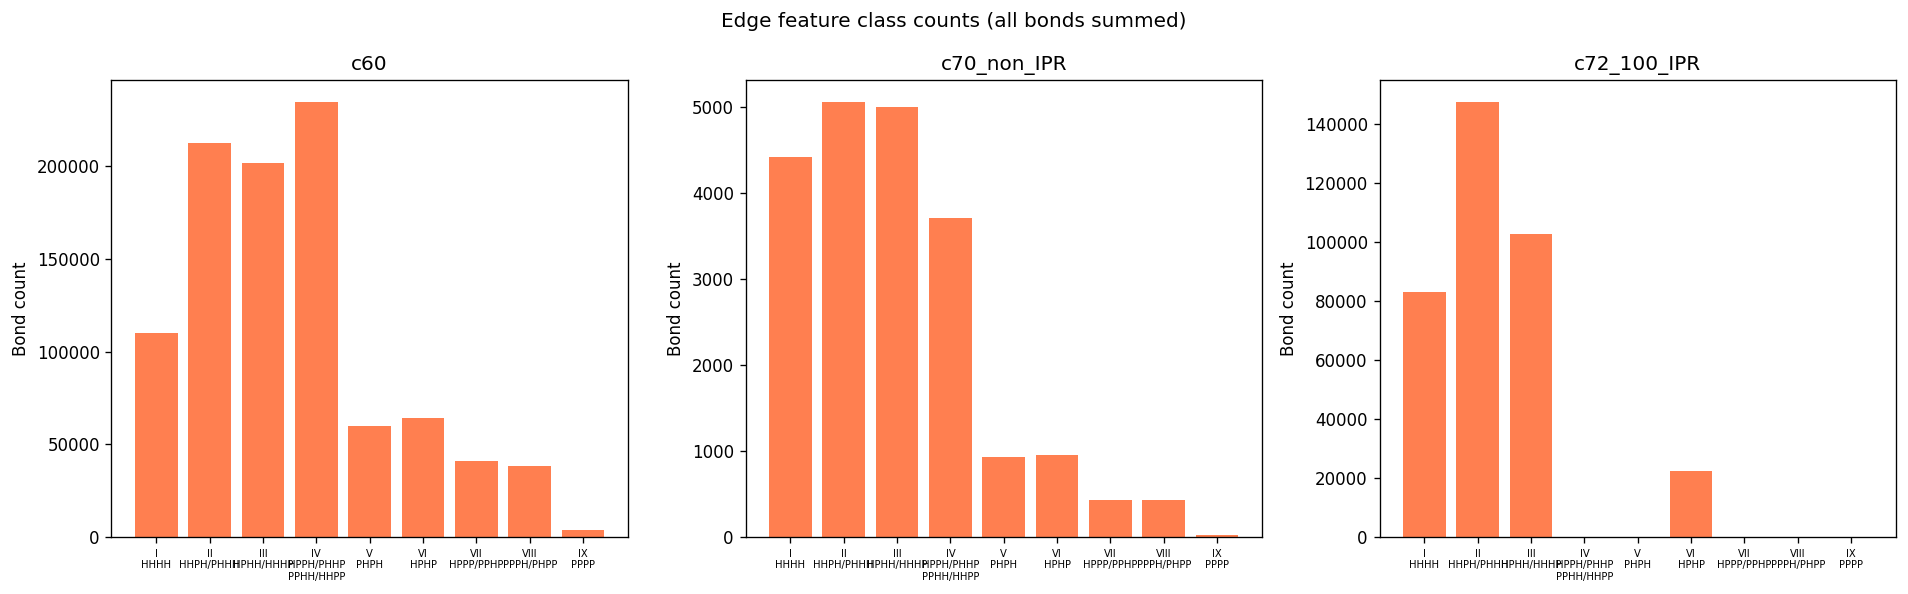

In [8]:
edge_class_names = ['I\nHHHH','II\nHHPH/PHHH','III\nHPHH/HHHP',
                    'IV\nHPPH/PHHP\nPPHH/HHPP','V\nPHPH','VI\nHPHP',
                    'VII\nHPPP/PPHP','VIII\nPPPH/PHPP','IX\nPPPP']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Edge feature class counts (all bonds summed)', fontsize=12)

for ax, name in zip(axes, ['c60', 'c70_non_IPR', 'c72_100_IPR']):
    all_edges = torch.cat(datasets[name]['edge'], dim=0)  # (total_bonds, 9)
    counts = all_edges.sum(dim=0).numpy()
    bars = ax.bar(range(9), counts, color='coral')
    ax.set_title(name)
    ax.set_ylabel('Bond count')
    ax.set_xticks(range(9))
    ax.set_xticklabels(edge_class_names, fontsize=6)

plt.tight_layout()
plt.show()

## 8. Pentagon Ring Feature Distribution
8 types (P0–P5) based on how many of the 5 surrounding rings are pentagons.

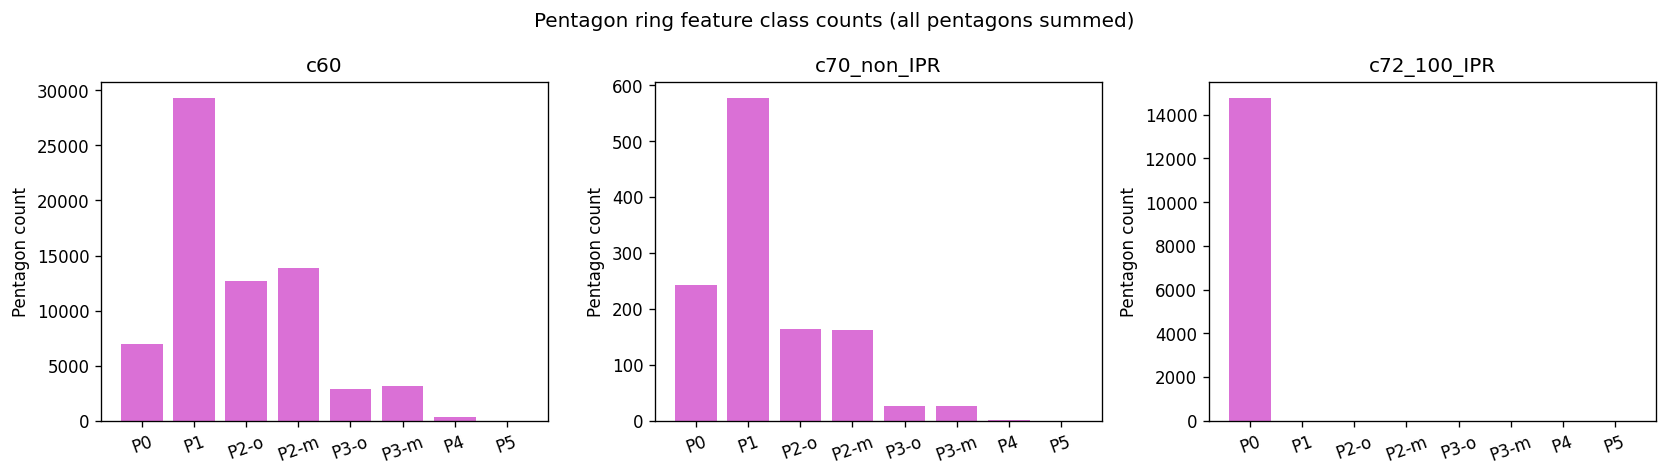

In [9]:
pent_labels = ['P0', 'P1', 'P2-o', 'P2-m', 'P3-o', 'P3-m', 'P4', 'P5']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Pentagon ring feature class counts (all pentagons summed)', fontsize=12)

for ax, name in zip(axes, ['c60', 'c70_non_IPR', 'c72_100_IPR']):
    all_pent = torch.cat(datasets[name]['pent'], dim=0)  # (total_pentagons, 8)
    counts = all_pent.sum(dim=0).numpy()
    ax.bar(pent_labels, counts, color='orchid')
    ax.set_title(name)
    ax.set_ylabel('Pentagon count')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 9. Hexagon Ring Feature Distribution
13 types (H0–H6) based on how many of the 6 surrounding rings are hexagons.

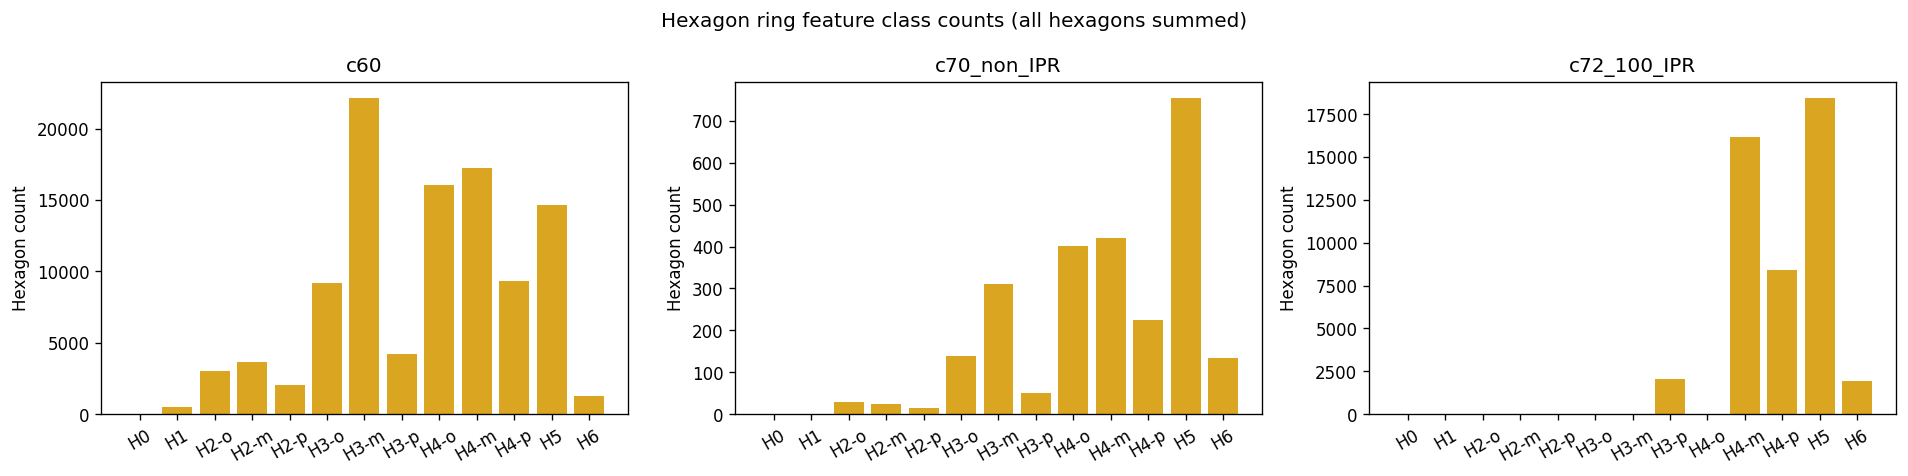

In [10]:
hex_labels = ['H0','H1','H2-o','H2-m','H2-p','H3-o','H3-m','H3-p','H4-o','H4-m','H4-p','H5','H6']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Hexagon ring feature class counts (all hexagons summed)', fontsize=12)

for ax, name in zip(axes, ['c60', 'c70_non_IPR', 'c72_100_IPR']):
    all_hex = torch.cat(datasets[name]['hex'], dim=0)  # (total_hexagons, 13)
    counts = all_hex.sum(dim=0).numpy()
    ax.bar(hex_labels, counts, color='goldenrod')
    ax.set_title(name)
    ax.set_ylabel('Hexagon count')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 10. Per-size Isomer Counts (c60 dataset)

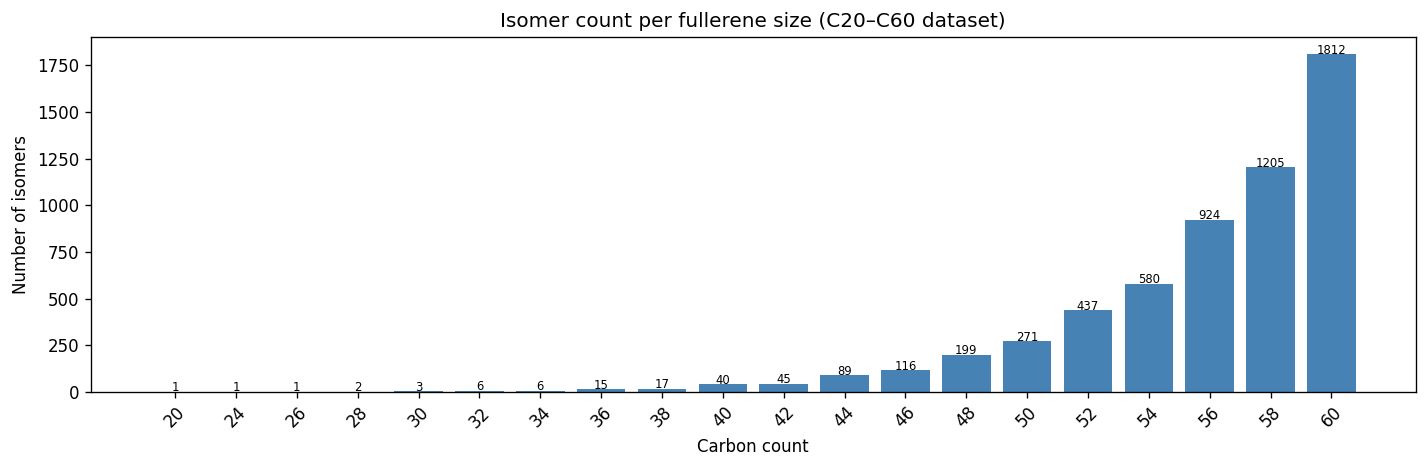

In [11]:
df = labels['c60']
iso_counts = df.groupby('#C').size()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(iso_counts.index.astype(str), iso_counts.values, color='steelblue')
ax.set_xlabel('Carbon count')
ax.set_ylabel('Number of isomers')
ax.set_title('Isomer count per fullerene size (C20–C60 dataset)')
ax.tick_params(axis='x', rotation=45)
for x, v in zip(range(len(iso_counts)), iso_counts.values):
    ax.text(x, v + 2, str(v), ha='center', fontsize=7)
plt.tight_layout()
plt.show()

## 11. Summary Table

In [12]:
rows = []
for name, d in datasets.items():
    df = labels[name]
    rows.append({
        'Dataset': name,
        'Molecules': len(d['node']),
        'Node feat dim': d['node'][0].shape[1],
        'Edge feat dim': d['edge'][0].shape[1],
        'Pent feat dim': d['pent'][0].shape[1],
        'Hex feat dim':  d['hex'][0].shape[1],
        'Pentagons/mol': d['pent'][0].shape[0],
        'Label columns': df.shape[1],
    })

pd.DataFrame(rows).set_index('Dataset')

,Molecules,Node feat dim,Edge feat dim,Pent feat dim,Hex feat dim,Pentagons/mol,Label columns
Dataset,,,,,,,
c60,5770,4,9,8,13,12,32
c70_non_IPR,100,4,9,8,13,12,20
c72_100_IPR,1230,4,9,8,13,12,18
